# Multiple Linear Regression

## 1. Introduction

So far, we have worked with a dataset containing only one feature: study hours. Each of the 20 training examples maps a number of study hours to an exam score. We then applied Gradient Descent to find the parameters $w$ and $b$ that minimize the cost function and obtain a linear regression model that makes accurate predictions.

> **Recap**
>
> Before we progress further, let us briefly recall the two core equations from the previous notebook.
>
> The prediction model was
>
> $$
> f(x)=wx+b,
> $$
>
> and the corresponding cost function was
>
> $$
> J(w,b)
> =
> \frac{1}{2m}
> \sum_{i=1}^{m}
> \left(f(x^{(i)})-y^{(i)}\right)^2.
> $$

In practice, study hours are likely to be a useful predictor of exam performance, but they are probably not the only factor influencing the result. Other features may also contain relevant information and help improve our predictions. To account for this, we will extend our previous Gradient Descent implementation so that it can optimize a linear regression model with multiple input features. Although the implementation changes, the underlying principle of Gradient Descent remains the same.

In addition, we will introduce two important concepts when working with data: feature scaling and feature engineering. Feature scaling makes Gradient Descent more stable and simplifies the choice of suitable hyperparameters by bringing the input features to comparable numerical scales. Feature engineering creates new features by combining or transforming existing ones, allowing the model to capture additional predictive relationships in the data.

At the end of this notebook, we will return to the sleep feature and modify the synthetic dataset so that sleep has a nonlinear relationship with the exam score. We will then use feature engineering and polynomial regression to represent this relationship while continuing to use a linear regression model.

> **Note**
>
> Throughout this notebook, we will refer to the implementation of Gradient Descent. The complete implementations of both univariate and multiple linear regression can be found in the `src/ml_from_scratch` directory.
>
> If you are interested in the behavior of the individual functions, you may also want to explore the unit tests in the `tests` directory. Besides verifying correctness, they provide additional examples of how the implementation is intended to be used.

Before moving on to the next chapter, execute the code cell below to import the required dependencies and generate the example dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from utils.helpers import (
    generate_multiple_linear_regression_dataset,
    create_dataset_table,
    standardize_features,
    compute_cost_history,
)

from utils.plotting import (
    plot_features_vs_target,
    plot_scaling_comparison,
    plot_cost_history,
    plot_cost_histories,
)

X, y = generate_multiple_linear_regression_dataset()

## 2. The Dataset

As mentioned in the introduction, we will now work with a dataset containing multiple features. Once again, we will use a synthetic dataset. Besides study hours, we will additionally consider lecture attendance, the number of completed practice tests, and the hours of sleep before the exam. Each feature represents a factor that could plausibly influence a student's exam performance.

Our dataset consists of 20 training examples and four input features. Together with the corresponding exam scores, the complete dataset contains 20 rows and five columns.

An important assumption of linear regression is that the relationship between each input feature and the target value is approximately linear. Therefore, we will initially assume that all four features have a linear relationship with the exam score.

In the next code cell, you can inspect the complete dataset.

In [12]:
table = create_dataset_table(X, y)
table

Training Example,Study Hours,Attendance (%),Practice Tests,Sleep (h),Exam Score
1,1,56.5,0,5.6,39.4
2,18,96.2,8,8.1,118.8
3,16,88.8,7,8.1,111.7
4,2,57.0,0,5.7,42.5
5,9,72.5,3,6.8,77.0
6,6,66.1,2,6.1,64.6
7,12,79.7,6,7.2,95.5
8,4,66.7,1,5.9,50.7
9,19,94.9,8,8.4,124.0
10,17,89.9,8,7.9,114.7


After inspecting the dataset, we can now introduce an important notation that will be used throughout the rest of this notebook.

In the previous notebook, we worked with only a single input feature. Therefore, we represented our training data by the feature vector $x \in \mathbb{R}^{20}$, where each element corresponded to the number of study hours of one training example.

Since our new dataset contains multiple input features, we now organize the input data in the feature matrix $X \in \mathbb{R}^{20 \times 4}$, where each row represents one training example and each column represents one feature.

The corresponding exam scores are stored separately in the target vector $y \in \mathbb{R}^{20}$.

To refer to an individual value in the feature matrix, we use the notation $x_j^{(i)}$, where the superscript \(i\) denotes the training example and the subscript \(j\) denotes the feature.

For example, $x_2^{(5)}$ refers to the value of the second feature (lecture attendance) of the fifth training example. You can verify this directly in the dataset shown above. The correct value is 72.5 % Attendance.

> **Note**
>
> In mathematical notation, indices usually start at 1. Therefore, the feature index is written as j = 1 ... n and the training example index as i = 1 ... m.
>
> In Python and NumPy, however, arrays use zero-based indexing. Throughout this notebook, we use mathematical indexing when discussing the theory and Python indexing when working with code.

Although the dataset table provides a good overview of the individual training examples, it can be difficult to recognize relationships between the input features and the target variable by simply looking at the numbers.

A visual representation often reveals patterns that are much harder to identify in tabular form. Therefore, the following plots show each feature against the exam score. Since the data was generated using a linear model, we expect to observe approximately linear relationships between every feature and the target variable.

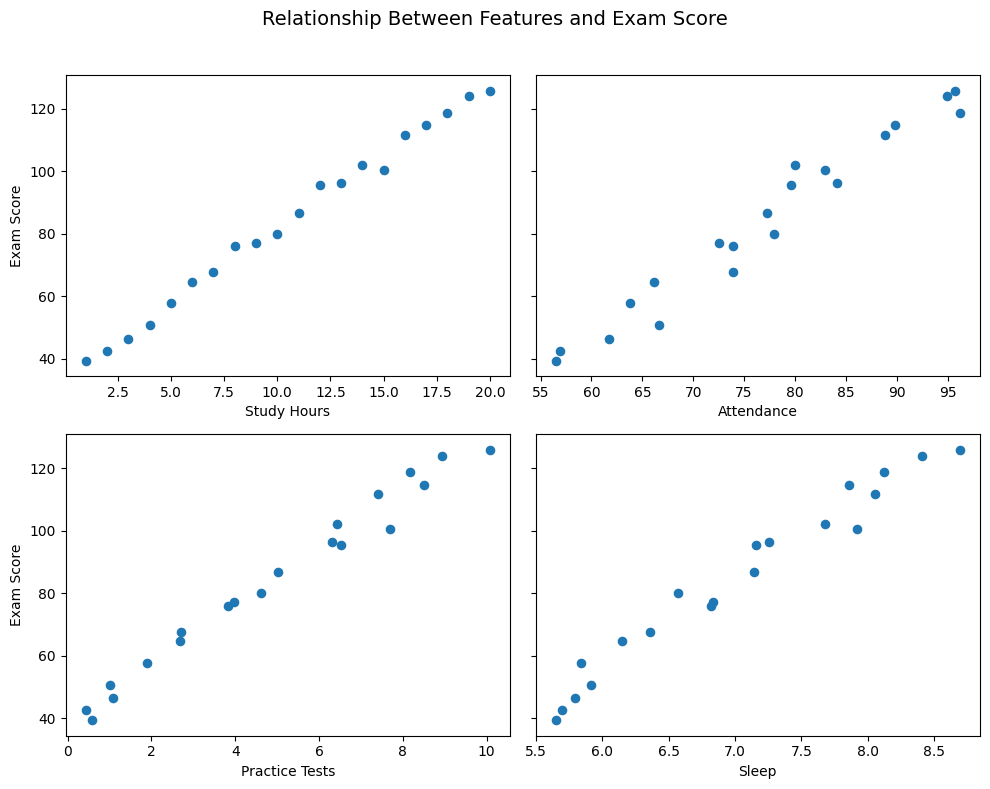

In [13]:
feature_names = ["Study Hours", "Attendance", "Practice Tests", "Sleep"]
plot_features_vs_target(X, y, feature_names)
plt.show()

Each feature exhibits an approximately linear relationship with the exam score. However, none of the features alone explains the target perfectly. This motivates combining all available features into a single prediction model, which is exactly what multiple linear regression does.

## 3. Multiple Linear Regression

Compared to univariate linear regression, the main difference is that our model now uses multiple input features instead of just one. Consequently, we no longer optimize a single weight parameter $w$, but a weight vector

$$
\mathbf{w} =
\begin{bmatrix}
w_1 \\
w_2 \\
\vdots \\
w_n
\end{bmatrix},
$$

where each weight corresponds to one input feature. In addition to the weight vector, the model still contains the bias parameter $b$.

The prediction model therefore becomes

$$
\hat{y}
=
w_1x_1+w_2x_2+\cdots+w_nx_n+b.
$$

Although the equation looks more complicated than in the univariate case, the underlying idea remains exactly the same. Each feature contributes to the prediction according to its corresponding weight, and the bias parameter shifts the prediction independently of the input features.

Instead of writing the weighted sum explicitly, we can express the same computation more compactly using vector notation:

$$
\hat{y}
=
\mathbf{w}^T\mathbf{x}+b.
$$

Here, $\mathbf{x}$ denotes the feature vector of a single training example, while $\mathbf{w}$ contains the corresponding weight parameters. The dot product computes the weighted sum of all input features and therefore produces a single prediction $\hat{y}$.

This compact notation will become particularly useful in the next chapter, where we extend gradient descent to optimize all weight parameters simultaneously.

## 4. Gradient Descent for Multiple Features

In the previous section, we derived the prediction model for a single training example. During training, however, Gradient Descent evaluates the cost function over the entire dataset rather than one training example at a time. To achieve this, we stack all feature vectors into the feature matrix $\mathbf{X}$ and process the complete dataset simultaneously.

> **Recap**
>
> Gradient Descent still follows exactly the same optimization principle as in the univariate case. The algorithm repeatedly updates the model parameters in the direction that decreases the cost function most rapidly. In the previous notebook, we visualized this process using the cost curve and the cost surface. With multiple weight parameters, such visualizations are no longer practical because the optimization takes place in a higher-dimensional parameter space.

Although the optimization problem has become larger, the overall learning algorithm remains exactly the same. We therefore revisit each component of the algorithm and extend it from one input feature to multiple input features.

**Prediction Model**

The prediction model for the entire dataset becomes

$$
\hat{\mathbf{y}}
=
\mathbf{X}\mathbf{w}+b,
$$

where each element of $\hat{\mathbf{y}}$ corresponds to the predicted exam score of one training example.

Compared to univariate linear regression, the implementation changes only slightly:

```python
# Univariate Linear Regression
y_hat = x * w + b

# Multiple Linear Regression
y_hat = X @ w + b
```

In the univariate case, `x * w` multiplies the feature vector element by element by the scalar weight $w$. In the multiple-feature case, the `@` operator performs matrix-vector multiplication between the feature matrix $\mathbf{X}$ and the weight vector $\mathbf{w}$.

This operation computes the predictions for all training examples simultaneously. It is therefore an example of vectorization: instead of calculating each prediction separately with a Python loop, NumPy processes the complete feature matrix in a single operation.

The scalar bias $b$ is then added to every element of the resulting prediction vector. We will return to vectorized operations later when computing all weight gradients simultaneously.

**Cost Function**

Once we can compute predictions for every training example, we can evaluate how well the model fits the entire dataset using the cost function.

The cost function now depends on multiple weight parameters and is written as

$$
J(w_1,\ldots,w_n,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right)^2.
$$

**Update Rules**

To minimize the cost function, we again apply Gradient Descent. Since the model contains one weight for each input feature, we must compute a separate partial derivative with respect to every weight.

For each weight $w_j$, the update rule is

$$
w_j
:=
w_j
-
\alpha
\frac{\partial}{\partial w_j}
J(w_1,\ldots,w_n,b),
$$

Here, $j$ identifies the feature and its corresponding weight. The bias parameter is updated in the same way:

$$
b
:=
b
-
\alpha
\frac{\partial}{\partial b}
J(w_1,\ldots,w_n,b).
$$

Each partial derivative describes how the cost changes with respect to one model parameter while all other parameters are held constant. During each iteration of Gradient Descent, all weights and the bias are updated simultaneously.

**Vectorized Gradient Computation**

Although each weight has its own partial derivative, we do not need to compute the gradients one by one. By using matrix multiplication, NumPy can calculate the complete weight gradient in a single vectorized operation.

The gradient with respect to the weight vector is

$$
\nabla_{\mathbf{w}}J
=
\frac{1}{m}
\mathbf{X}^{T}
(\hat{\mathbf{y}}-\mathbf{y}).
$$

The vector

$$
\hat{\mathbf{y}}-\mathbf{y}
$$

contains the prediction error for every training example. Multiplying this error vector by the transposed feature matrix $\mathbf{X}^{T}$ combines the errors with their corresponding feature values and produces one gradient for each weight.

The derivative with respect to the bias is

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)}-y^{(i)}\right).
$$

Since the bias is added equally to every prediction, its gradient is simply the average prediction error over all training examples.

These equations correspond directly to our implementation:

```python
error = predict(X, w, b) - y

dj_dw = X.T @ error / m
dj_db = np.sum(error) / m
```

Here, `X.T @ error` performs matrix-vector multiplication and returns the complete weight gradient as a vector. The sum of all prediction errors gives the gradient for the scalar bias parameter.

This is another example of vectorization. Instead of iterating explicitly over every training example and every feature with nested Python loops, NumPy performs the required operations internally. This makes the implementation shorter and easier to read and is generally much faster because NumPy relies on optimized numerical routines.

> **Note**
>
> Vectorization is one of the most important concepts in scientific computing with NumPy. Many machine learning libraries, including scikit-learn, TensorFlow, and PyTorch, rely heavily on vectorized operations instead of explicit Python loops.

At this point, all components required to train the multiple linear regression model are in place. Before starting the training process, however, we need to examine the numerical ranges of the input features.

In the next chapter, we will introduce feature scaling and investigate how transforming the features to comparable numerical scales affects the convergence behavior of Gradient Descent.

## 5. Feature Scaling

Our input features have very different numerical ranges. For example, study hours may range from approximately 1 to 20, while attendance may range from approximately 50 to 100. These differences can negatively affect the optimization process and make Gradient Descent more sensitive to the choice of the learning rate.

The reason is that the magnitude of a partial derivative depends partly on the numerical values of its corresponding feature. Features with larger values can therefore produce much larger gradients than features with smaller values. However, Gradient Descent uses the same learning rate $\alpha$ to update all weight parameters:

$$
w_j
:=
w_j
-
\alpha
\frac{\partial J}{\partial w_j}.
$$

A learning rate that produces reasonable updates for one weight may therefore produce overly large updates for another. As a result, Gradient Descent may oscillate around the minimum, converge slowly, or even diverge. In the case of divergence, the parameter updates move the model farther away from the minimum, causing the cost to grow rather than converge.

To make the optimization process more stable and easier to tune, we can transform all features to comparable numerical scales. This preprocessing step is called feature scaling.

Several feature-scaling methods exist. In this notebook, we will use z-score standardization. For each feature $j$, we first calculate its mean $\mu_j$ and standard deviation $\sigma_j$. We then transform every value using

$$
x_{j,\mathrm{scaled}}^{(i)}
=
\frac{x_j^{(i)}-\mu_j}{\sigma_j}.
$$

After this transformation, each feature has approximately $\text{mean} = 0$ and $\text{standard deviation} = 1$.

The transformed values are therefore usually concentrated within a relatively small range around zero. They do not need to share exactly the same minimum and maximum values. The important point is that their numerical scales are now comparable.

NumPy allows us to apply this transformation to the complete feature matrix using vectorized operations. In the next code cell, we will perform z-score standardization and compare the study-hours and attendance features before and after scaling.

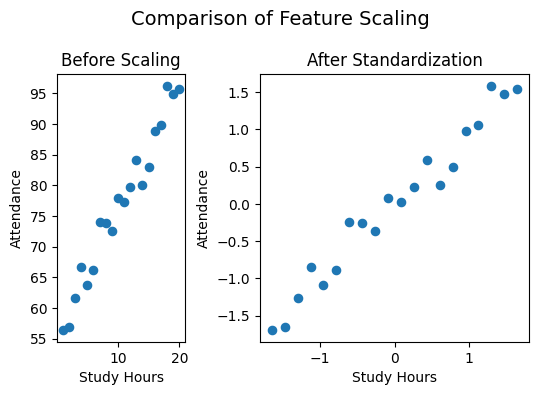

In [22]:
X_standardized = standardize_features(X)

X_subset = X[:, [0, 1]].copy()
X_subset_standardized = X_standardized[:, [0, 1]].copy()
feature_names = ["Study Hours", "Attendance"]

plot_scaling_comparison(X_subset, X_subset_standardized, feature_names)
plt.show()

The effect of z-score standardization can be summarized as follows:

| Feature | Range before | Range after | Mean before | Mean after | Std. before | Std. after |
|---|---:|---:|---:|---:|---:|---:|
| Study Hours | 1.00–20.00 | -1.65–1.65 | 10.50 | 0.00 | 5.77 | 1.00 |
| Attendance | 56.49–96.20 | -1.69–1.58 | 77.00 | 0.00 | 12.14 | 1.00 |

After standardization, both features are centered around zero and have a standard deviation of one. Their minimum and maximum values are not identical, but the features now have comparable numerical scales. The relative arrangement of the data points remains unchanged because standardization only shifts and rescales each feature.

**Effect on Gradient Descent**

To examine how feature scaling affects the optimization process, we now train the model using both the standardized and unstandardized feature matrices. For a meaningful comparison, both training runs use the same initial parameters, learning rate, and number of iterations.

During training, we record the value of the cost function after each iteration. This sequence of values is called the cost history. It allows us to observe whether Gradient Descent converges, oscillates, or diverges.

For both training runs, we use a learning rate of $\alpha = 3.2 \cdot 10^{-4}$ and train the model for 100 iterations.

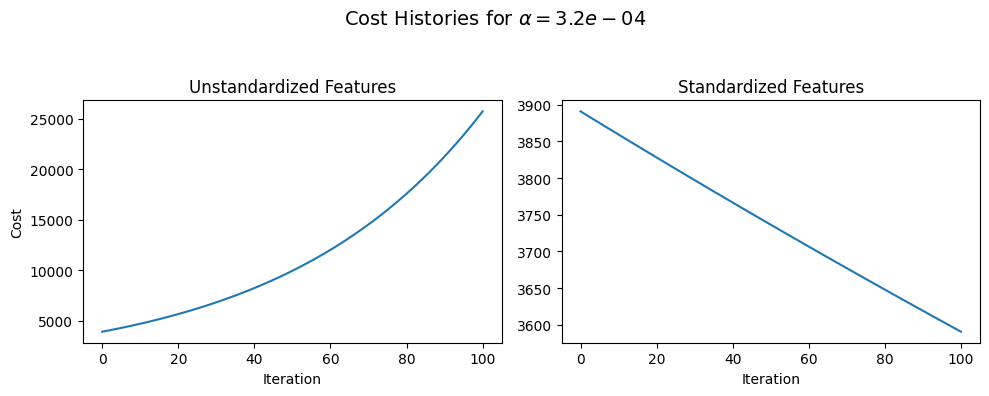

In [23]:
learning_rate = 3.2e-4
iterations = 100

w_init = np.zeros(X.shape[1])
b_init = 0

feature_matrices = [X, X_standardized]

axes_titles = ["Unstandardized Features", "Standardized Features"]
fig_title = rf"Cost Histories for $\alpha = {learning_rate:.1e}$"
fig_size = (10, 4)

cost_histories = []

for feature_matrix in feature_matrices:
    cost_history = compute_cost_history(
        feature_matrix, 
        y,
        w_init, 
        b_init, 
        learning_rate, 
        iterations
    )
    cost_histories.append(cost_history)

plot_cost_histories(cost_histories, fig_title, axes_titles, fig_size)

plt.show()

With the unstandardized features, the cost increases substantially over the course of training. The parameter updates are too large for the different feature scales, causing Gradient Descent to diverge.

In contrast, the cost of the standardized model continues to decrease with the same learning rate. The decrease is relatively slow because the chosen learning rate is small for the standardized features, but the optimization process remains stable.

This comparison shows that feature scaling allows Gradient Descent to remain stable for learning rates that already cause divergence with unstandardized features. It therefore makes the optimization process less sensitive to the numerical ranges of the input features.

After standardization, the features are centered around zero and have comparable standard deviations. This makes the range of suitable learning rates more predictable and allows us to test more commonly used values. Feature scaling therefore makes Gradient Descent not only more stable, but also easier to tune.

Although the standardized features remain stable with this learning rate, the cost decreases only slowly. This suggests that the chosen value of $\alpha$ is safe, but not necessarily efficient. In the following chapter, we will explore how different learning rates affect the cost history and develop a systematic approach to choosing suitable hyperparameters.

## 6. Hyperparameters and Convergence

A practical approach to choosing the learning rate is to begin with a relatively small value and train the model for a limited number of iterations. We then examine the cost history and gradually increase $\alpha$ until the updates become unstable or the algorithm begins to diverge.

Learning rates are often tested over several orders of magnitude, for example

$$
0.001,\;0.003,\;0.01,\;0.03,\;0.1,\;0.3,\;1.
$$

The appropriate range depends on the problem and the numerical scale of the input features. Since our features have already been standardized, we can now compare these learning rates under more suitable conditions.

In the following plots, we keep the number of iterations fixed and compare the resulting cost histories. A learning rate that is too small should produce a slowly decreasing cost, while a suitable value should converge more rapidly. If the learning rate becomes too large, the cost may oscillate or increase.

Once an appropriate learning rate has been identified, we can determine how many iterations are required. Too few iterations stop the optimization before convergence, while unnecessarily many iterations increase the computational effort without producing a meaningful improvement.

We therefore continue training until the cost no longer decreases significantly. The final choice of the number of iterations depends on both the selected learning rate and the convergence behavior shown by the cost history.

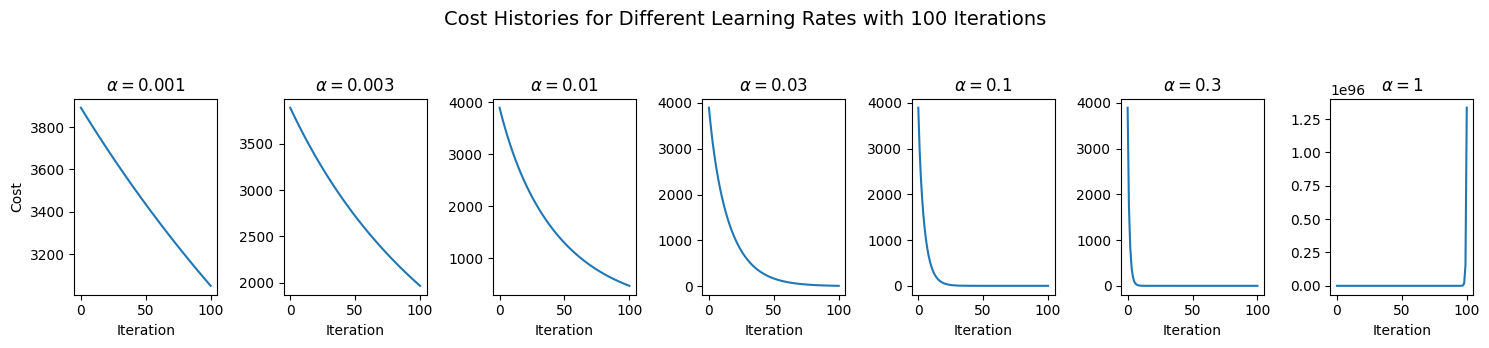

In [24]:
learning_rates = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1]
iterations = 100
w_init = np.zeros(X_standardized.shape[1])
b_init = 0

axes_titles = [rf"$\alpha = {learning_rate}$" for learning_rate in learning_rates]
fig_title = f"Cost Histories for Different Learning Rates with 100 Iterations"
fig_size = (15, 3.5)

cost_histories = []

for learning_rate in learning_rates:
    cost_history = compute_cost_history(
        X_standardized,
        y,
        w_init,
        b_init,
        learning_rate,
        iterations
    )
    cost_histories.append(cost_history)

plot_cost_histories(cost_histories, fig_title, axes_titles, fig_size)

plt.show()

As shown in the plots, the cost generally decreases more rapidly as the learning rate increases. Among the tested values, a learning rate of $\alpha = 0.3$ produces the fastest stable convergence. At this point, the cost may already begin to show slight oscillations, indicating that the updates are becoming more aggressive.

A learning rate of $\alpha = 1$ causes Gradient Descent to diverge. The cost grows so rapidly that Matplotlib displays the y-axis using a scale factor of approximately $10^{95}$.

Based on these results, we choose $\alpha = 0.3$ for the final model. Since our synthetic dataset is small and the cost decreases rapidly, we can also reduce the number of iterations to 20. In practice, larger or more complex datasets may require substantially more iterations.

Before continuing with the next chapter on feature engineering, we take one final look at the cost history for the selected hyperparameters.

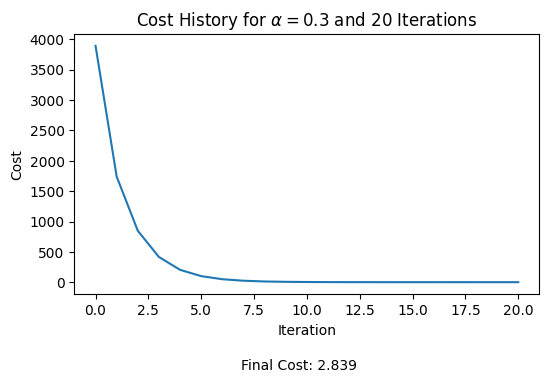

In [25]:
learning_rate = 3e-1
iterations = 20
w_init = np.zeros(X_standardized.shape[1])
b_init = 0

ax_title = rf"Cost History for $\alpha = {learning_rate}$ and {iterations} Iterations"

cost_history = compute_cost_history(
    X_standardized,
    y,
    w_init,
    b_init,
    learning_rate,
    iterations
)

plot_cost_history(cost_history, ax_title)

plt.show()

The cost still decreases slightly during the final iterations, which means that Gradient Descent continues to make small improvements. However, the change has become very small. You can observe this yourself by increasing the number of iterations in the code cell.

At this point, we must decide whether the minor reduction in cost justifies additional computation. Choosing the number of iterations therefore involves a trade-off between further optimization and computational effort.

## 7. Feature Engineering

The predictive performance of a machine learning model depends not only on the algorithm itself, but also on how the input data is represented. Feature engineering is the process of creating new features from the original input features in order to provide the model with additional useful information.

New features can be created by combining or transforming existing features. For example, two features may be multiplied, divided, or otherwise combined to represent a relationship that is not captured by the original features alone. However, adding more features does not automatically improve the model. An engineered feature is only useful if it provides an additional predictive contribution to the target variable. Irrelevant or redundant features may add complexity without improving the predictions. Identifying useful features often requires domain knowledge and intuition. Understanding the problem domain can help us recognize relationships that may not be obvious from the original feature representation.

Feature engineering can therefore improve model accuracy by allowing the model to capture patterns that would otherwise remain hidden. At the same time, each new feature should have a meaningful connection to the prediction problem.

In the next chapter, we will return to the sleep feature introduced earlier in the notebook and modify the dataset so that sleep has a nonlinear relationship with the exam score. We will then use feature engineering to transform the original sleep feature into polynomial features. This allows the linear regression model to represent a nonlinear relationship while remaining linear in its parameters. This approach is known as polynomial regression.



## 8. Polynomial Regression